In [1]:
!pip install scipy

In [2]:
!pip install pandas

In [3]:
from scipy.io import loadmat
import pandas as pd
import numpy as np
import glob
import os

In [4]:


data_path = "/Users/lubhanamutha/Desktop/BMS/NASA/kaggle_data/data"   # relative path
files = sorted(glob.glob(os.path.join(data_path, "*.csv")))
df = pd.read_csv(files[0])
print(df.columns.tolist())


['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time']


In [5]:
valid_files = []

for f in files:
    df = pd.read_csv(f)
    cols = df.columns.str.strip().str.lower()

    if (
        "time" in cols.tolist()
        and "current_measured" in cols.tolist()
        and len(df) > 10
    ):
        valid_files.append(f)

print(f"Valid cycles: {len(valid_files)} / {len(files)}")

files = valid_files


Valid cycles: 5580 / 7565


In [8]:
for file_path in valid_files:
    df = pd.read_csv(file_path)

    # 1. Drop invalid rows
    df = df.dropna(
        subset=["Voltage_measured", "Current_measured", "Temperature_measured"]
    )

    # 2. Convert Time → Timedelta
    df["Time_td"] = pd.to_timedelta(df["Time"], unit="s")

    # 3. Sort by time
    df = df.sort_values("Time_td").reset_index(drop=True)

    # 4. Resample to uniform 1-second grid (KEEP Time_td)
    df = (
        df.set_index("Time_td")
          .resample("1s")
          .mean()
          .interpolate()
    )

    # 5. Create uniform numeric time (seconds)
    df["Time_uniform"] = df.index.total_seconds()

    # 6. Now derivatives are physically correct
    df["dV_dt"] = df["Voltage_measured"].diff()
    df["dT_dt"] = df["Temperature_measured"].diff()

    # (optional) reset index if model needs flat DF
    df = df.reset_index(drop=True)

    print(df.head())


   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.246711          0.000252              6.212696        0.0002   
1          4.246717          0.000068              6.215065        0.0002   
2          4.246723         -0.000117              6.217435        0.0002   
3          4.246729         -0.000302              6.219804        0.0002   
4          4.246735         -0.000487              6.222173        0.0002   

   Voltage_load  Time  Time_uniform     dV_dt     dT_dt  
0      0.000000  0.00           0.0       NaN       NaN  
1      0.473556  1.04           1.0  0.000006  0.002369  
2      0.947111  2.08           2.0  0.000006  0.002369  
3      1.420667  3.12           3.0  0.000006  0.002369  
4      1.894222  4.16           4.0  0.000006  0.002369  
   Voltage_measured  Current_measured  Temperature_measured  Current_charge  \
0          3.486189          0.001417              5.990142        -0.00060   
1          3.616391          0.

EDA

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = Path("processed_common")

dfs = []
for file in processed_dir.glob("*.csv"):
    df = pd.read_csv(file)
    df["cycle_id"] = file.stem
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(data.head())
print(data.columns)


   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.193564         -0.002804              5.006658        0.0004   
1          4.193486         -0.002787              5.011360        0.0004   
2          4.193408         -0.002770              5.016061        0.0004   
3          4.193331         -0.002753              5.020762        0.0004   
4          4.193253         -0.002736              5.025464        0.0004   

   Voltage_load  Time_uniform     dV_dt     dT_dt      cycle_id  \
0      0.000000           0.0       NaN       NaN  00081_common   
1      0.467667           1.0 -0.000078  0.004701  00081_common   
2      0.935333           2.0 -0.000078  0.004701  00081_common   
3      1.403000           3.0 -0.000078  0.004701  00081_common   
4      1.870667           4.0 -0.000078  0.004701  00081_common   

   Current_charge  Voltage_charge  
0             NaN             NaN  
1             NaN             NaN  
2             NaN         

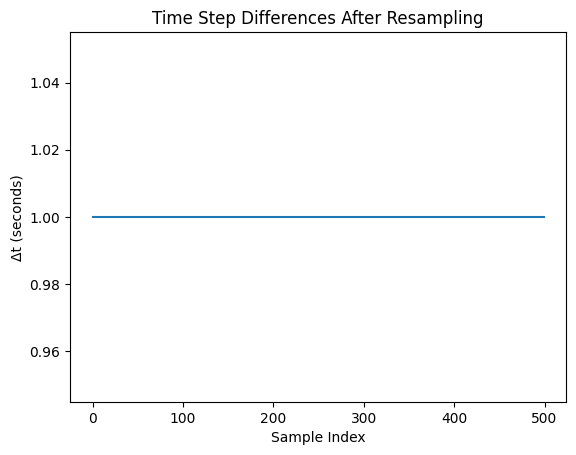

In [10]:
plt.figure()
plt.plot(data["Time_uniform"].diff().dropna().values[:500])
plt.title("Time Step Differences After Resampling")
plt.ylabel("Δt (seconds)")
plt.xlabel("Sample Index")
plt.show()


The plot shows a perfectly constant time-step difference of 1 second across all samples after resampling, indicating that the originally irregular time series has been successfully converted into a uniformly sampled sequence. This confirms that temporal jitter and logging inconsistencies present in the raw data have been effectively removed through resampling and interpolation. As a result, all subsequent feature computations, such as temporal derivatives and cumulative integrations, are now based on a consistent time interval, ensuring physical correctness and temporal alignment across cycles.

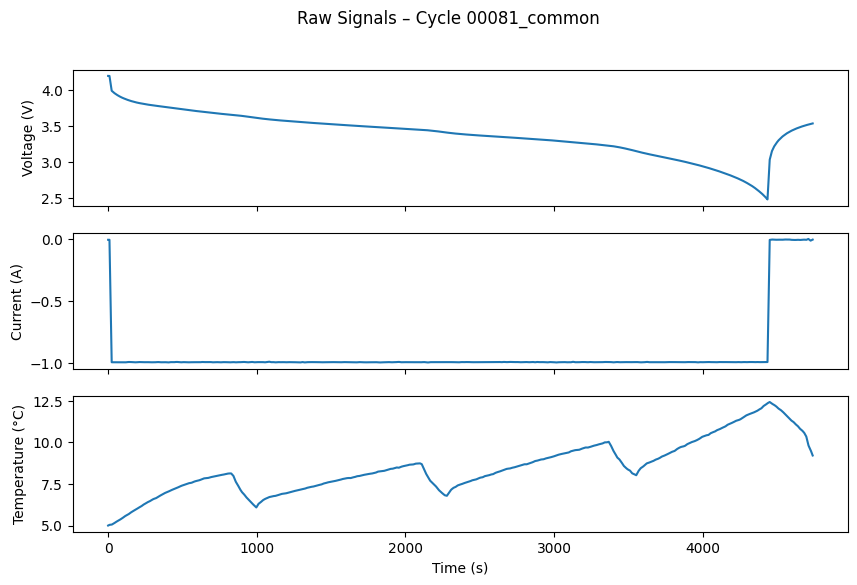

In [20]:
cycle = data["cycle_id"].iloc[0]
df_c = data[data["cycle_id"] == cycle]

fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10,6))

ax[0].plot(df_c["Time_uniform"], df_c["Voltage_measured"])
ax[0].set_ylabel("Voltage (V)")

ax[1].plot(df_c["Time_uniform"], df_c["Current_measured"])
ax[1].set_ylabel("Current (A)")

ax[2].plot(df_c["Time_uniform"], df_c["Temperature_measured"])
ax[2].set_ylabel("Temperature (°C)")
ax[2].set_xlabel("Time (s)")

plt.suptitle(f"Raw Signals – Cycle {cycle}")
plt.show()


The voltage profile shows a smooth and monotonic decrease over time, characteristic of a controlled discharge process, with a sharp voltage drop near the end indicating proximity to the lower cutoff region. The current remains nearly constant at approximately −1 A throughout most of the cycle, confirming a stable constant-current discharge, while the abrupt transition at the end reflects discharge termination. The temperature signal exhibits a gradual rise with periodic drops, likely corresponding to brief rest phases or changes in thermal conditions, highlighting the coupling between electrical load and thermal behavior. Overall, the signals are smooth, physically consistent, and free from irregular artifacts, indicating that the common preprocessing and resampling steps have preserved the true battery dynamics.

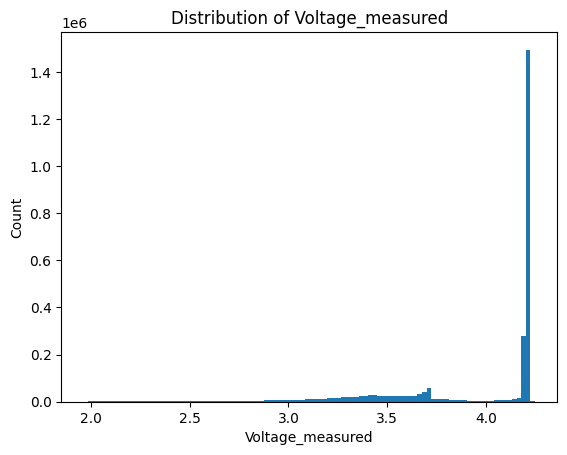

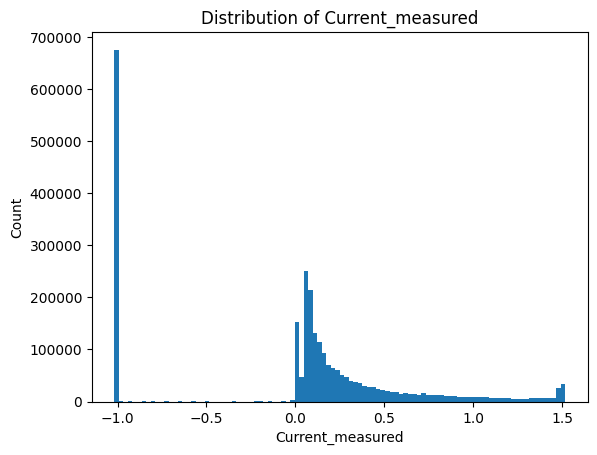

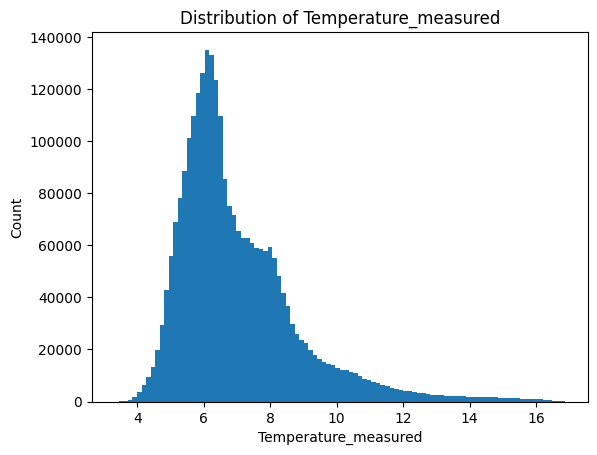

In [12]:
features = ["Voltage_measured", "Current_measured", "Temperature_measured"]

for col in features:
    plt.figure()
    plt.hist(data[col], bins=100)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


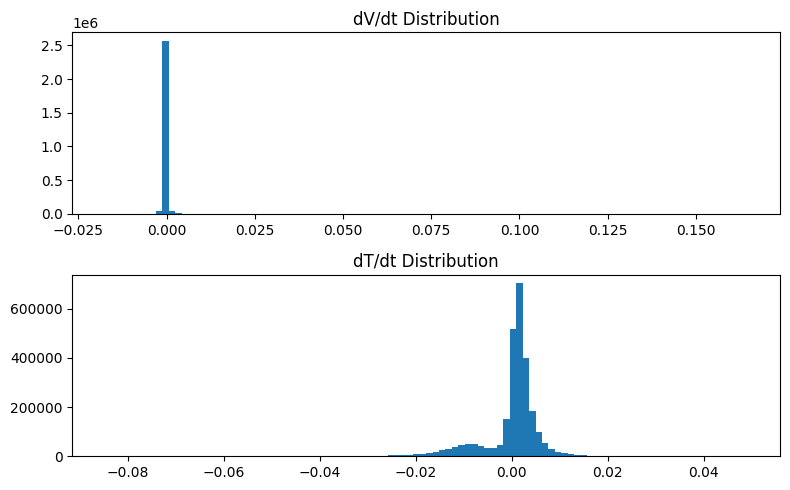

In [13]:
fig, ax = plt.subplots(2,1, figsize=(8,5))

ax[0].hist(data["dV_dt"].dropna(), bins=100)
ax[0].set_title("dV/dt Distribution")

ax[1].hist(data["dT_dt"].dropna(), bins=100)
ax[1].set_title("dT/dt Distribution")

plt.tight_layout()
plt.show()


The distributions of voltage, current, and temperature after common preprocessing exhibit physically realistic yet highly non-Gaussian behavior, reflecting the true operating characteristics of lithium-ion battery discharge cycles. Voltage values are heavily concentrated near higher levels, indicating prolonged operation in nominal voltage regions, while lower voltage states are comparatively rare and occur near the end of discharge. The current distribution is strongly multimodal, dominated by a constant-current discharge regime with additional modes corresponding to rest and transition phases. Temperature shows a right-skewed distribution, capturing gradual heat accumulation and thermal stress under sustained load. Together, these distributions confirm that the preprocessing pipeline preserves genuine electro-thermal dynamics rather than imposing artificial smoothing or statistical regularity.
What to Worry About (Important)

Strong distribution imbalance
Most samples lie in high-voltage, constant-current, and low-temperature regions, which may bias learning toward early and mid-cycle behavior while under-representing end-of-discharge conditions.

Non-Gaussian feature distributions
None of the signals follow a normal distribution, meaning models that rely on Gaussian assumptions or simple linear relationships may perform poorly.

Dominant operating regimes
The strong peaks in current and voltage indicate limited variability in operating modes, which may reduce model sensitivity to rare but critical transitions unless sequence-aware learning is used.

Coupled electro-thermal behavior
Temperature increases are correlated with prolonged discharge, implying that thermal effects must be considered jointly with electrical signals rather than treated as independent noise.

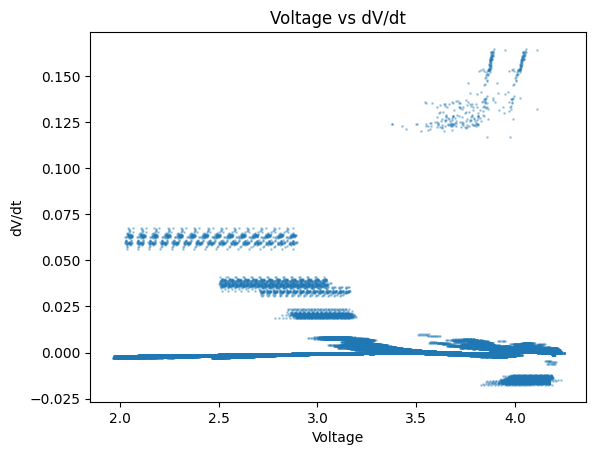

In [14]:
plt.figure()
plt.scatter(
    data["Voltage_measured"],
    data["dV_dt"],
    s=1,
    alpha=0.3
)
plt.xlabel("Voltage")
plt.ylabel("dV/dt")
plt.title("Voltage vs dV/dt")
plt.show()


The voltage versus dV/dt scatter plot reveals clear clustered structures corresponding to distinct electrochemical operating regimes during battery operation. Near higher voltage levels, dV/dt values are close to zero, indicating slow voltage change and stable behavior typical of mid-discharge constant-current operation. As voltage decreases, multiple horizontal and sloped bands emerge, reflecting increased polarization effects and faster voltage decay near end-of-discharge regions. The presence of well-defined clusters rather than a continuous cloud indicates that voltage dynamics are piecewise and state-dependent, governed by underlying battery physics rather than random measurement noise.

Strong regime separation
The presence of discrete clusters means that voltage dynamics change abruptly across operating regions, which simple linear or global models may fail to capture.

Nonlinear and non-smooth behavior
The relationship between voltage and its rate of change is highly nonlinear, especially at lower voltages, making static regression assumptions invalid.

Rare but critical regions
High dV/dt values at lower voltage levels represent short but critical operating phases that are under-represented and may be difficult for models to learn without sufficient temporal context.

Sensitivity to noise amplification
Derivative-based features can amplify small measurement errors, requiring careful normalization and robust modeling.


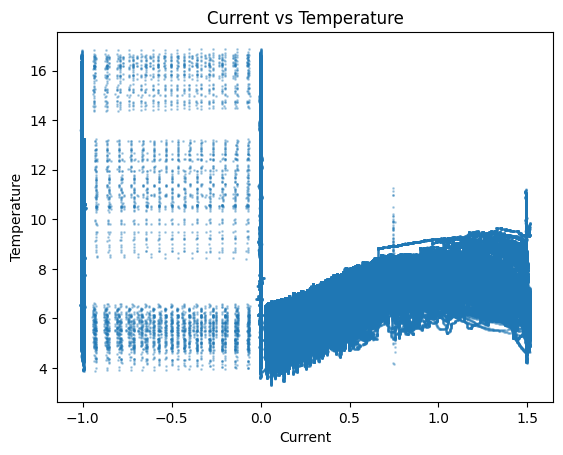

In [16]:
plt.figure()
plt.scatter(
    data["Current_measured"],
    data["Temperature_measured"],
    s=1,
    alpha=0.3
)
plt.xlabel("Current")
plt.ylabel("Temperature")
plt.title("Current vs Temperature")
plt.show()


The current versus temperature scatter plot reveals a strong coupling between electrical load and thermal response, characterized by distinct operating regimes. At negative current values (discharge), temperature remains within a relatively bounded range, reflecting stable heat generation under constant-current discharge. Near zero current, vertical clusters appear, corresponding to rest or transition phases where temperature changes occur without significant current flow. At positive current values, temperature increases progressively with increasing current magnitude, indicating enhanced heat generation due to resistive losses. The structured clustering pattern confirms that temperature evolution is strongly state-dependent and governed by operating conditions rather than random fluctuations.
What to Worry About (Important)

Nonlinear electro-thermal relationship
Temperature does not vary linearly with current, particularly across sign changes and transition regions, which can challenge simple regression models.

Distinct operating regimes
The presence of multiple clusters implies abrupt regime shifts (discharge, rest, recovery, load changes) that must be learned temporally rather than statically.

Imbalanced data density
Large portions of the data lie in dominant discharge regimes, while transition and high-current regions are comparatively sparse, risking under-learning of critical thermal stress states.

Thermal inertia effects
Temperature continues to evolve even when current approaches zero, indicating delayed thermal response that models must capture using historical context.

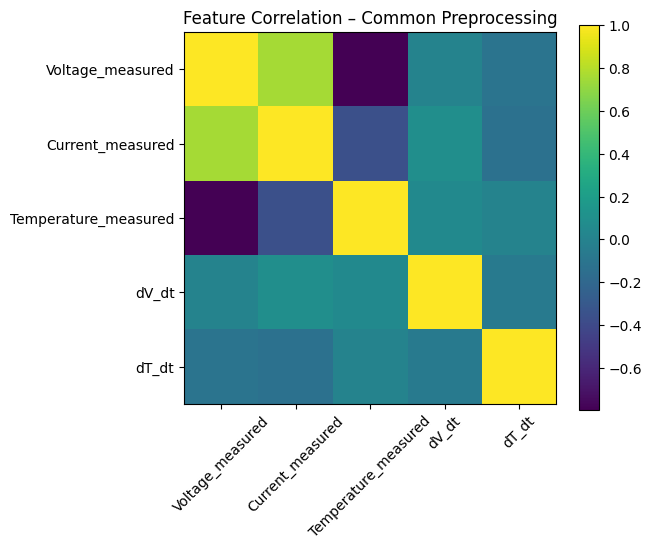

In [17]:
corr_cols = [
    "Voltage_measured",
    "Current_measured",
    "Temperature_measured",
    "dV_dt",
    "dT_dt"
]

corr = data[corr_cols].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Feature Correlation – Common Preprocessing")
plt.show()


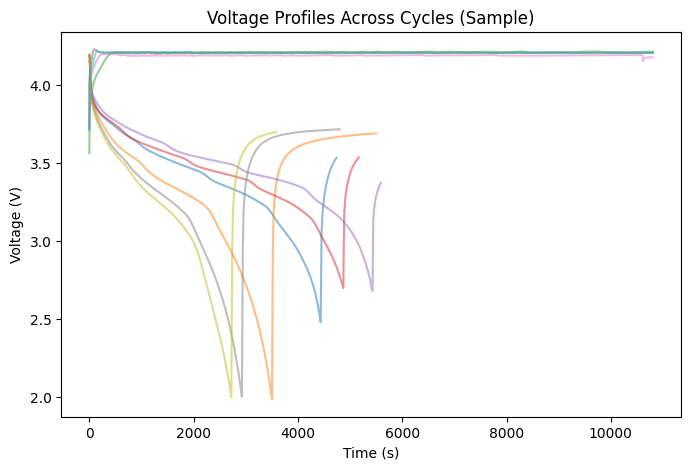

In [18]:
plt.figure(figsize=(8,5))

for cid in data["cycle_id"].unique()[:10]:
    df_c = data[data["cycle_id"] == cid]
    plt.plot(df_c["Time_uniform"], df_c["Voltage_measured"], alpha=0.5)

plt.title("Voltage Profiles Across Cycles (Sample)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.show()


The voltage profiles across different cycles show a consistent overall discharge shape, with an initial rapid voltage drop followed by a gradual decline and a sharp fall near end-of-discharge. However, clear variations are observed in both discharge duration and voltage trajectory across cycles, with some cycles reaching cutoff voltage earlier than others. These differences reflect progressive capacity fade, increased internal resistance, and aging-related changes in electrochemical behavior. Despite this variability, the overall shape similarity across cycles indicates that the common preprocessing preserves temporal alignment and physical discharge characteristics.

What to Worry About (Important)

Cycle-to-cycle variability
Significant differences in discharge duration and cutoff timing indicate non-uniform aging behavior, which must be explicitly modeled rather than averaged out.

Early cutoff in later cycles
Some cycles terminate at higher voltages and shorter times, suggesting reduced usable capacity and increased internal resistance that can impact SOC and SOH estimation.

Non-stationary voltage behavior
Voltage–time relationships shift across cycles, meaning models trained on early-cycle behavior may not generalize well to aged cycles.

Imbalanced temporal coverage
Longer cycles dominate the time-series data, potentially biasing models toward healthier battery states unless windowing or weighting strategies are applied.

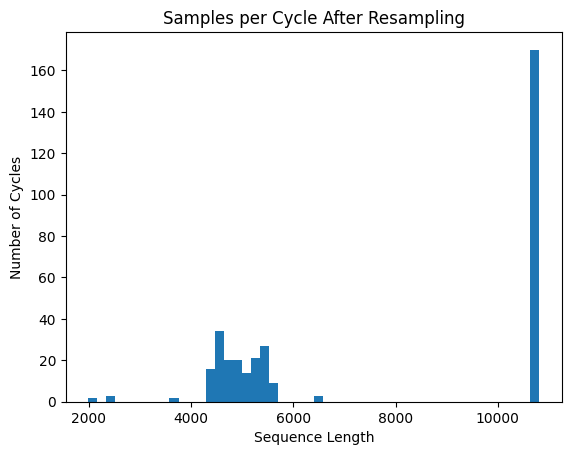

count      341.000000
mean      7830.803519
std       3005.594769
min       1992.000000
25%       4889.000000
50%       6437.000000
75%      10806.000000
max      10811.000000
dtype: float64


In [19]:
lengths = data.groupby("cycle_id").size()

plt.figure()
plt.hist(lengths, bins=50)
plt.title("Samples per Cycle After Resampling")
plt.xlabel("Sequence Length")
plt.ylabel("Number of Cycles")
plt.show()

print(lengths.describe())


The histogram shows that the number of samples per cycle after resampling varies significantly across cycles, indicating substantial differences in discharge duration. Most cycles cluster around a mid-range sequence length, while a small number of cycles extend to very long durations, forming a pronounced right tail. This variability reflects differences in usable capacity, operating conditions, and aging effects across cycles. The presence of longer sequences suggests healthier or earlier-life cycles, whereas shorter sequences correspond to aged cycles that reach cutoff earlier. Overall, the plot confirms that while resampling enforces uniform time steps, cycle lengths remain inherently non-uniform due to physical degradation.
Highly variable sequence lengths
Transformers require fixed-length inputs, so raw cycles cannot be fed directly without padding, truncation, or windowing.

Dominance of long cycles
A small number of very long cycles may dominate the dataset, biasing the model toward early-life battery behavior.

Under-representation of late-life behavior
Shorter cycles, which are critical for SOH and end-of-life modeling, appear less frequently and may be under-learned.

Risk of information loss during truncation
Naively cutting all sequences to the same length may discard important end-of-discharge dynamics.

What You Should Be Careful About Going Forward

Avoid models that assume linearity, stationarity, or feature independence

Do not train on full cycles directly due to variable sequence lengths

Prevent bias toward early-life, long cycles during training

Ensure rare late-life behavior is sufficiently represented